In [1]:
from pathlib import Path
import sys

In [34]:
import pandas as pd
import numpy as np
import seaborn as sns

In [27]:
from imblearn.pipeline import Pipeline
from imblearn import FunctionSampler
from sklearn.preprocessing import RobustScaler
from sklearn.svm import OneClassSVM
from sklearn.model_selection import cross_validate
from sklearn.metrics import (
    classification_report,
    PrecisionRecallDisplay,
    make_scorer ,
    precision_score, recall_score, f1_score, average_precision_score
    )

In [4]:
# Enable imports from the parent directory
parent_dir = '..'
sys.path.append(parent_dir)

from utils import draw_pr_curve_from_cv_results, print_cv_results

In [5]:
data_dir = Path('../../results')
train = pd.read_csv(data_dir / 'train_clean.csv')
test = pd.read_csv(data_dir / 'test_clean.csv')

In [6]:
num_cols = train.dtypes[(train.dtypes == 'float64') | (train.dtypes == 'int64')].index
target_feat = 'hasAwards'

In [7]:
train_X, train_y = train[num_cols], train[target_feat].map({True:-1, False:1})
test_X, test_y = test[num_cols], test[target_feat].map({True:-1, False:1})

In [8]:
train_y.value_counts()

hasAwards
 1    96128
-1     8536
Name: count, dtype: int64

The base idea is to use `FunctionSampler` to remove titles that received awards from the training set and check if they are classified as anomalous on the test set.

In [9]:
def remove_positive_class(X, y):
    return X[y == 1], y[y == 1]

In [10]:
sampler = FunctionSampler(func=remove_positive_class)

In [11]:
estimator = Pipeline([
    ('scaler', RobustScaler()),
    ('sampler', sampler),
    ('svm', OneClassSVM())
])

## Validation

In [13]:
scoring = dict(
    precision=make_scorer(precision_score, pos_label=-1),
    recall=make_scorer(recall_score, pos_label=-1),
    f1=make_scorer(f1_score, pos_label=-1),
    average_precision=make_scorer(average_precision_score, pos_label=-1)
)

In [14]:
%%time
results = cross_validate(
    estimator,
    train_X,
    train_y,
    scoring=scoring,
    n_jobs=-1,
    return_estimator=True,
    return_indices=True
)

CPU times: user 1.58 s, sys: 734 ms, total: 2.31 s
Wall time: 6min 43s


In [16]:
print_cv_results(results)

precision: 0.1 (0.0)
recall: 0.62 (0.01)
f1: 0.17 (0.0)
average_precision: 0.07 (0.0)


## Test

In [19]:
estimator.fit(train_X, train_y)

,steps,"[('scaler', ...), ('sampler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,with_centering,True
,with_scaling,True
,quantile_range,"(25.0, ...)"
,copy,True
,unit_variance,False
,func,<function rem...x7fdef82913a0>
,accept_sparse,True


In [20]:
y_pred = estimator.predict(test_X)

In [21]:
print(classification_report(y_true=test_y, y_pred=y_pred))

              precision    recall  f1-score   support

          -1       0.10      0.63      0.18      3805
           1       0.94      0.50      0.65     41052

    accuracy                           0.51     44857
   macro avg       0.52      0.56      0.42     44857
weighted avg       0.86      0.51      0.61     44857



In [30]:
scores = estimator.score_samples(test_X)

In [35]:
test['score'] = scores

In [37]:
test.groupby('hasAwards')['score'].describe()

,count,mean,std,min,25%,50%,75%,max
hasAwards,,,,,,,,
False,41052.0,8417.317614,2373.909846,41.290336,7038.999829,8791.233898,10106.686948,14158.423936
True,3805.0,7004.737735,3423.708676,4.316636,4309.889591,7704.144068,9800.461880,13633.821086


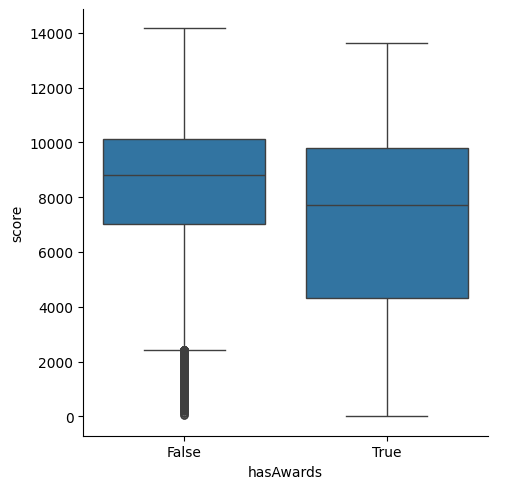

In [44]:
sns.catplot(test, x='hasAwards', y='score', kind='box')

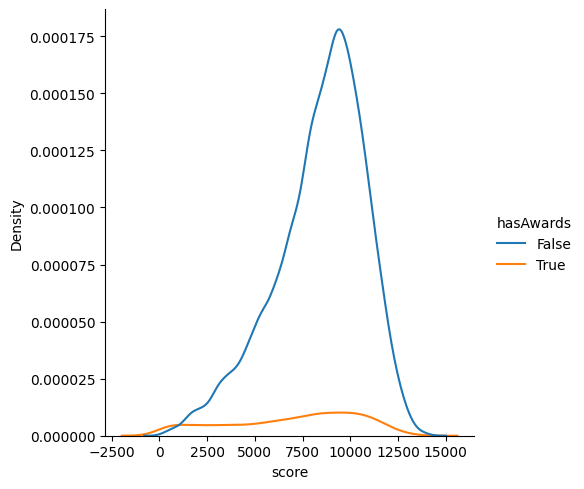

In [45]:
sns.displot(test, x='score', hue='hasAwards', kind='kde')